**Objective:**
To develop a machine learning model using XGBoost that can accurately classify  banking transactions as fraudulent or genuine based on transaction details,  customer behavior, account information, and risk-related features

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

# Step 1: Upload the file
uploaded = files.upload()

# Step 2: Read the Excel file
df = pd.read_csv('DecisionTree-XGBoost_dataset.csv')

# Step 3: Display data
df.head()

Saving DecisionTree-XGBoost_dataset.csv to DecisionTree-XGBoost_dataset.csv


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(50000, 21)

Column Names:
Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label'],
      dtype='object')

Data Types:
Transaction_ID                   object
User_ID                          object
Transaction_Amount              float64
Transaction_Type                 object
Timestamp                        object
Account_Balance                 float64
Device_Type                      object
Location                         object
Merchant_Category                object
IP_Address_Flag                   int64
Previous_Fraudulent_Activity      int64
Daily_Transaction_Count    

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64


In [ ]:
df['Fraud_Label'].value_counts()

,count
Fraud_Label,
0,33933
1,16067


In [ ]:
df['Fraud_Label'].value_counts(normalize=True)*100

,proportion
Fraud_Label,
0,67.866
1,32.134


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour

df.drop('Timestamp', axis=1, inplace=True)

df

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,...,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,Year,Month,Day,Hour
0,TXN_33553,USER_1834,39.79,POS,93213.17,Laptop,Sydney,Travel,0,0,...,65,883.17,Biometric,0.8494,0,0,2023,8,14,19
1,TXN_9427,USER_7875,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,0,...,186,2203.36,Password,0.0959,0,1,2023,6,7,4
2,TXN_199,USER_2734,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,0,...,226,1909.29,Biometric,0.8400,0,1,2023,6,20,15
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,0,...,76,1311.86,OTP,0.7935,0,1,2023,12,7,0
4,TXN_39489,USER_2014,31.28,POS,92354.66,Mobile,Mumbai,Electronics,0,1,...,140,966.98,Password,0.3819,1,1,2023,11,11,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TXN_11284,USER_4796,45.05,Online,76960.11,Mobile,Tokyo,Clothing,0,0,...,98,1537.54,PIN,0.1493,1,0,2023,1,29,18
49996,TXN_44732,USER_1171,126.15,POS,28791.75,Mobile,Tokyo,Clothing,0,0,...,93,2555.72,Biometric,0.3653,0,1,2023,5,9,8
49997,TXN_38158,USER_2510,72.02,Online,29916.41,Laptop,Mumbai,Clothing,0,1,...,114,4686.59,Biometric,0.5195,0,0,2023,1,30,19
49998,TXN_860,USER_2248,64.89,Bank Transfer,67895.67,Mobile,Tokyo,Electronics,0,0,...,72,4886.92,Biometric,0.7063,0,1,2023,3,9,19


In [ ]:
df.drop(['Transaction_ID', 'User_ID'],axis=1, inplace=True)

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category',
       'Card_Type', 'Authentication_Method'],
      dtype='object')

In [ ]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Fraud_Label', axis=1)

y = df['Fraud_Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)


In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)

In [ ]:

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9993


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6782    5]
 [   2 3211]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6787
           1       1.00      1.00      1.00      3213

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                         Feature  Importance
10   Failed_Transaction_Count_7d    0.587424
15                    Risk_Score    0.401792
13          Transaction_Distance    0.000785
7   Previous_Fraudulent_Activity    0.000765
16                    Is_Weekend    0.000745
12                      Card_Age    0.000738
2                Account_Balance    0.000721
20                          Hour    0.000696
5              Merchant_Category    0.000670
1               Transaction_Type    0.000663
0             Transaction_Amount    0.000616
19                           Day    0.000608
8        Daily_Transaction_Count    0.000563
9      Avg_Transaction_Amount_7d    0.000532
4                       Location    0.000522


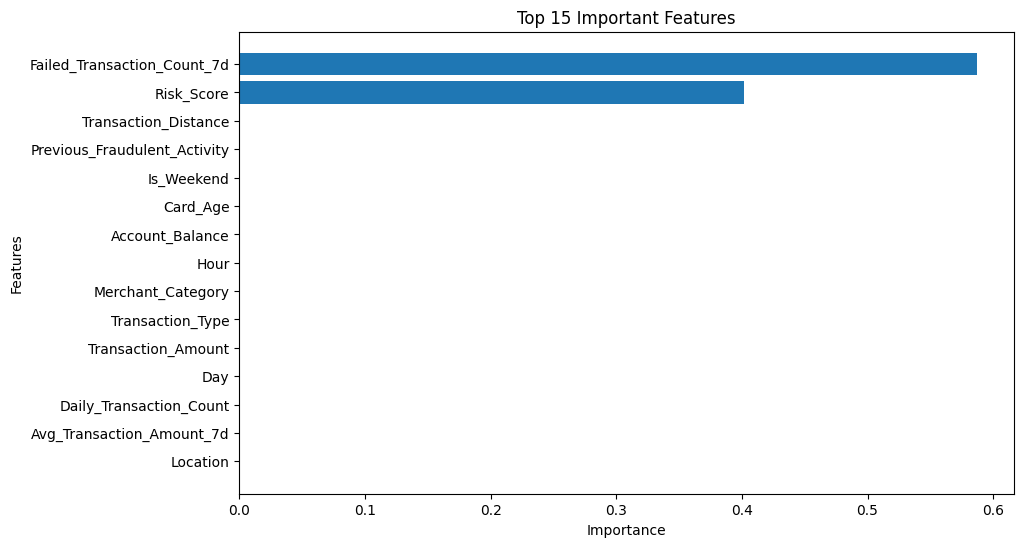

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:15],
    feature_importance['Importance'][:15]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

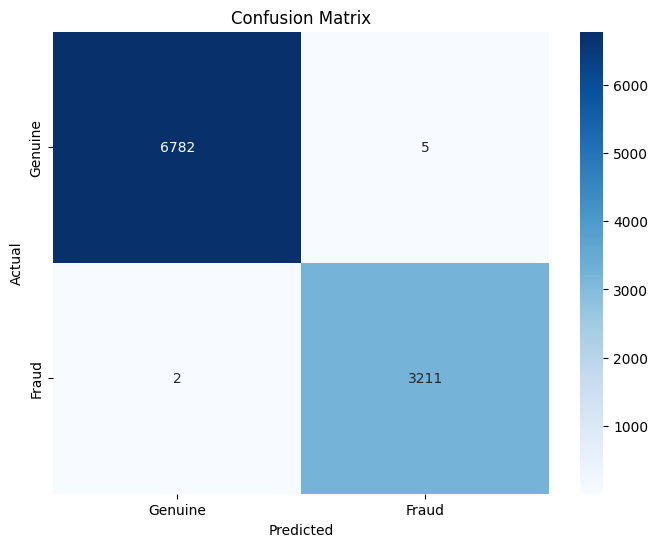

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

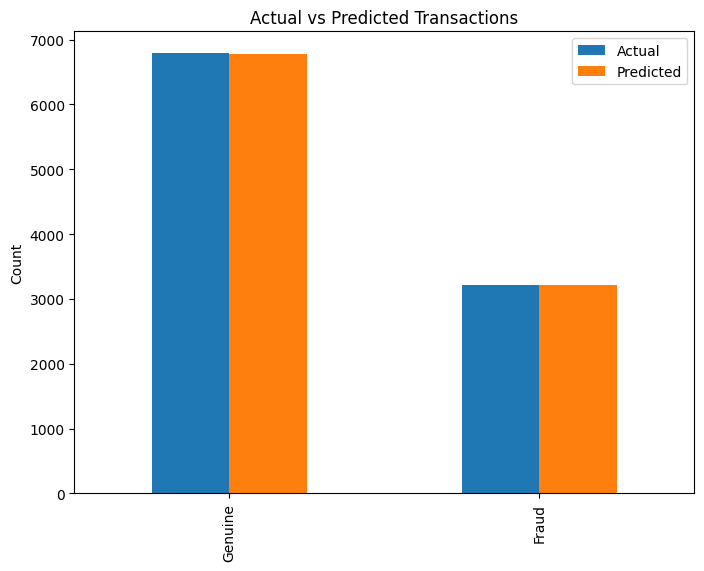

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

actual_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

comparison = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': pred_counts
})

comparison.index = ['Genuine', 'Fraud']

comparison.plot(
    kind='bar',
    figsize=(8,6)
)

plt.title("Actual vs Predicted Transactions")
plt.ylabel("Count")

plt.show()

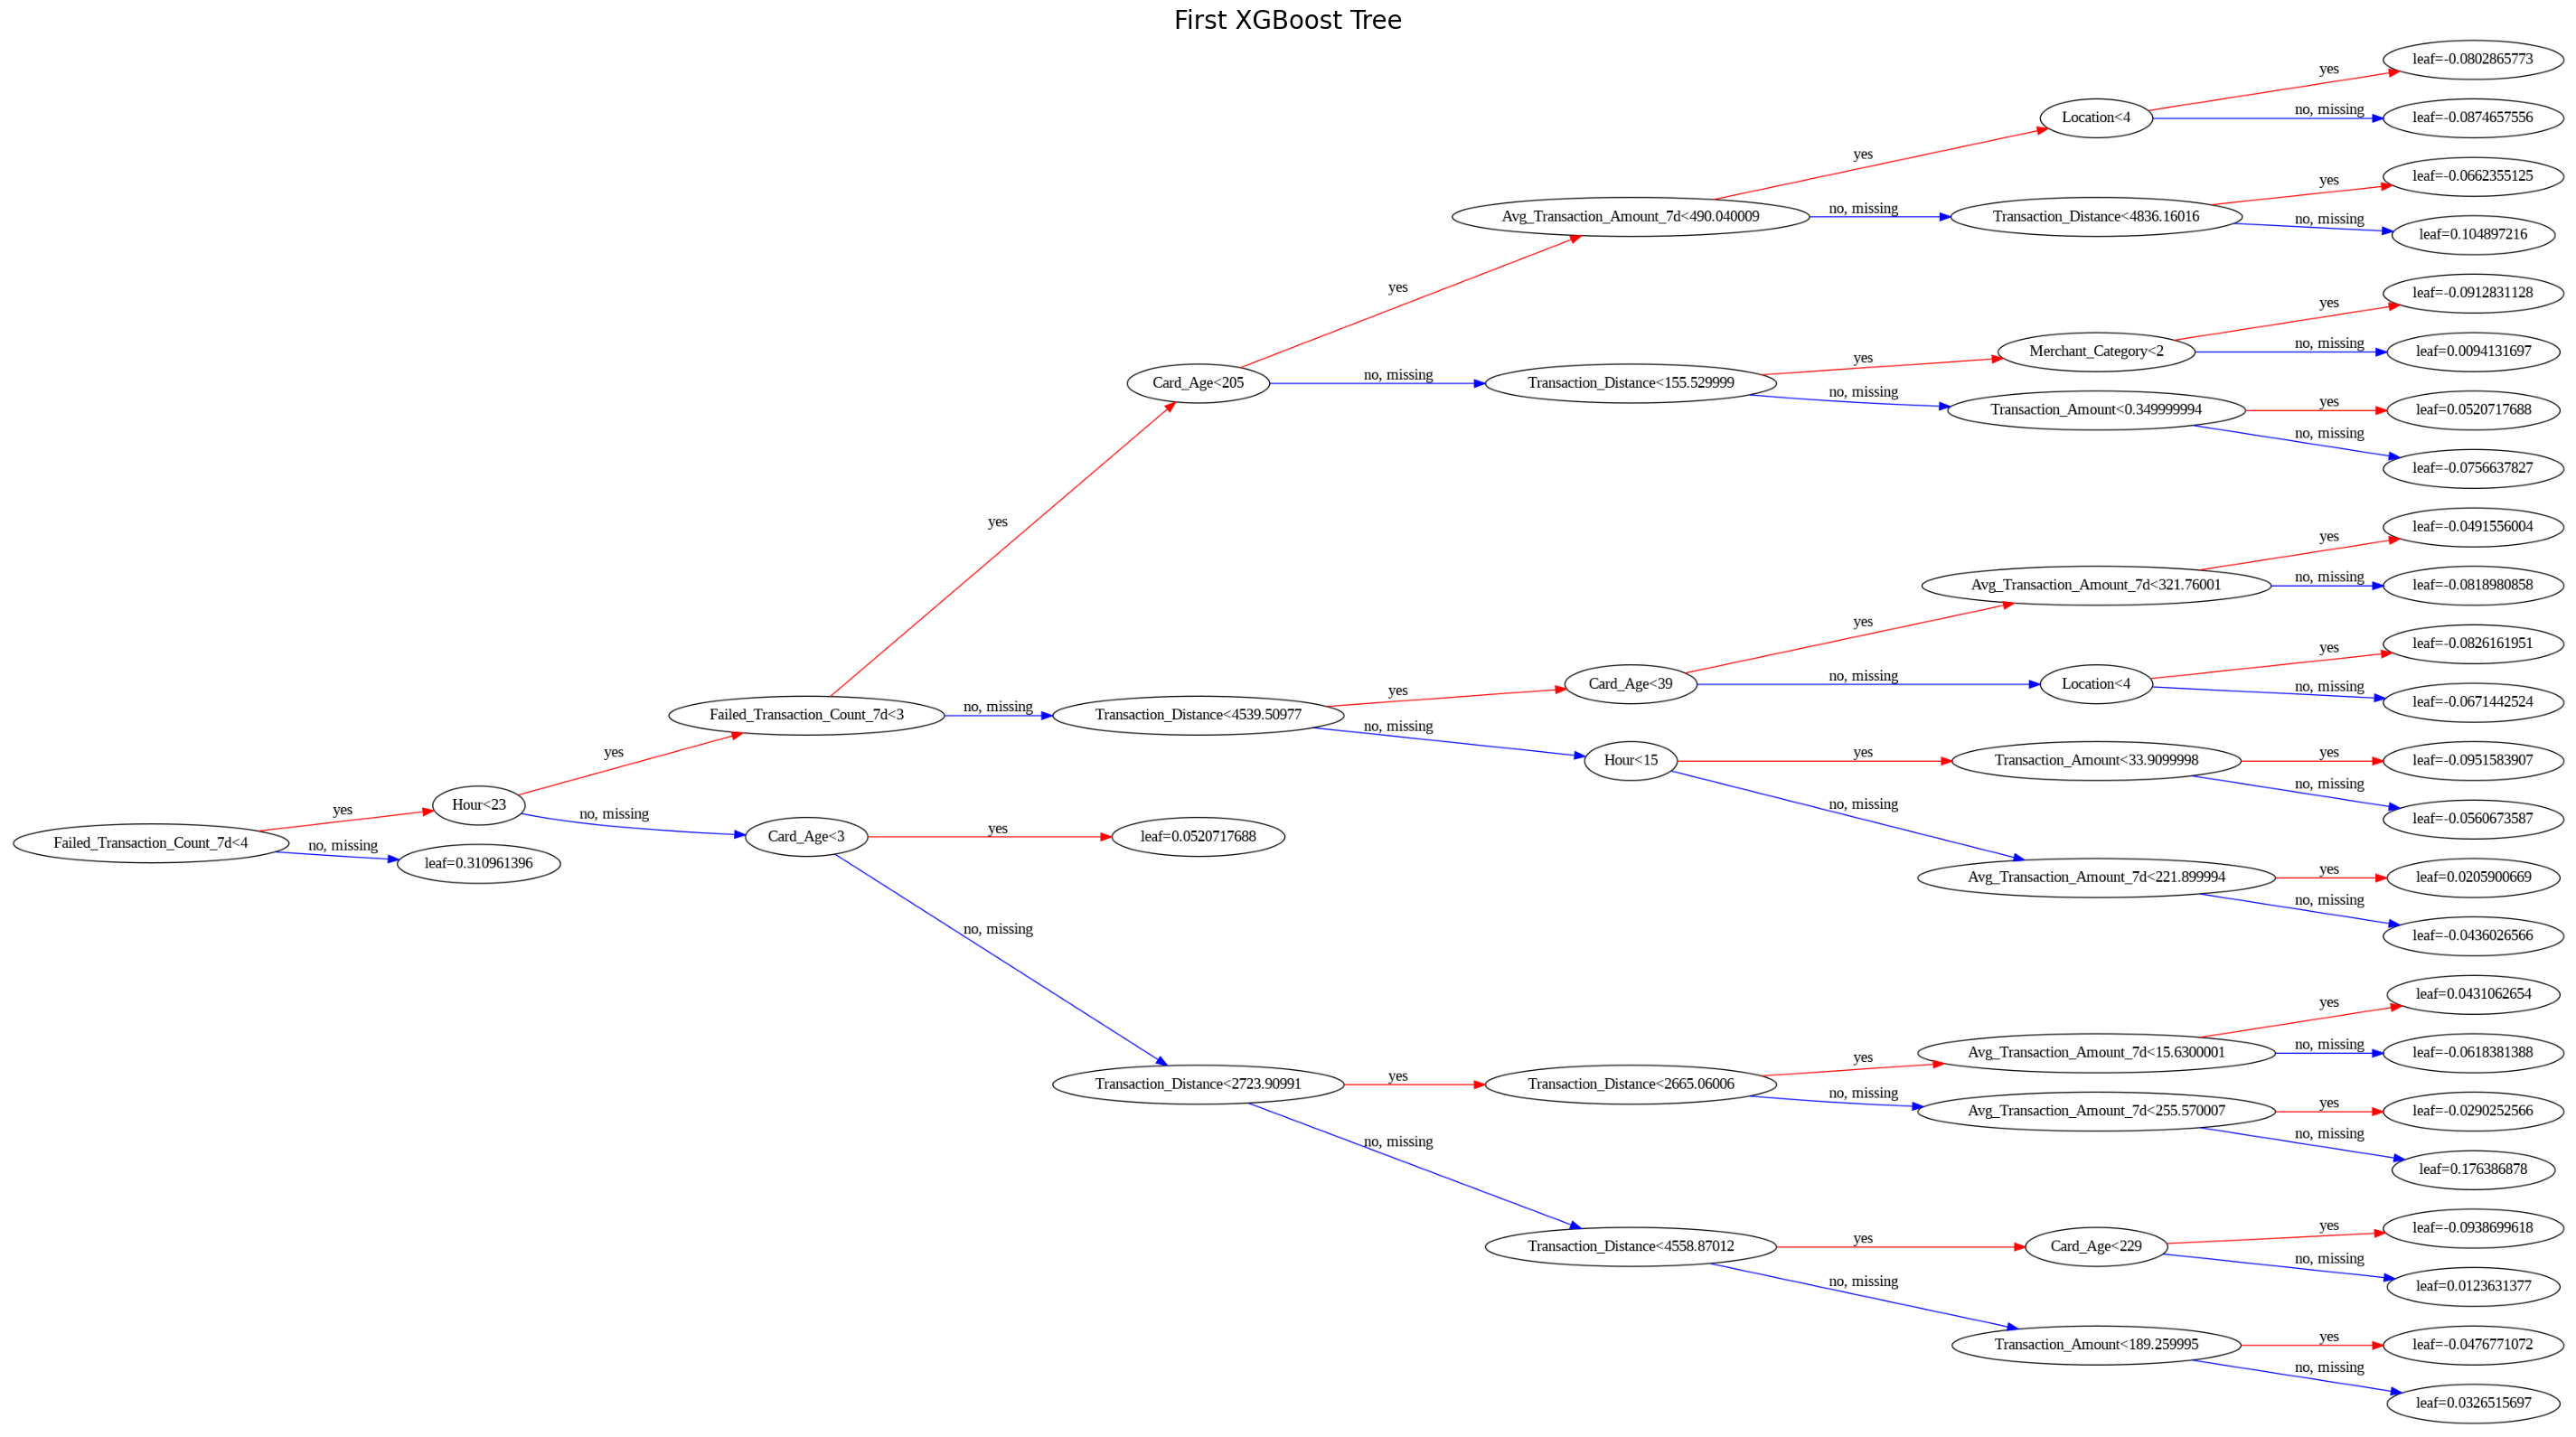

In [ ]:
from xgboost import plot_tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(40,20))

plot_tree(
    xgb_model,
    num_trees=0,
    rankdir='LR',
    ax=ax
)

plt.title("First XGBoost Tree", fontsize=20)
plt.show()